# L12b Lab: Learn a Grid-World Policy from Experience

> **Learning objectives**
>
> - Train a seeded tabular Q-learning agent.
> - Extract a greedy policy without assigning actions to terminal states.
> - Inspect learning returns and final exploration probability.
> - Evaluate the learned policy from a fixed start state.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week12Core` module from [`../src/Week12Core.jl`](../src/Week12Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this lab's local source are loaded. The cell below builds the learning grid world in `world::NamedTuple`, trains a seeded tabular agent into `learned::NamedTuple` (fields `Q::Matrix{Float64}`, `returns::Vector{Float64}`, `final_epsilon::Float64`, and `policy::Vector{Int64}`), and scores the greedy policy in `evaluation::NamedTuple`, which reports `mean_return::Float64`. The per-state summary is `policy_table::DataFrame`.


In [2]:
world = learning_gridworld(slip = 0.1, gamma = 0.95)
learned = q_learning(world; episodes = 20_000, seed = 5800)
evaluation = evaluate_policy(world, learned.policy; episodes = 2000, seed = 5800)

policy_labels = [world.terminal[state] ? "terminal" : world.action_names[learned.policy[state]] for state in eachindex(world.coordinates)]
policy_table = DataFrame(state = eachindex(world.coordinates), coordinate = string.(world.coordinates),
    action = policy_labels, max_Q = vec(maximum(learned.Q; dims = 2)))
pretty_table(policy_table)
(final_epsilon = learned.final_epsilon, mean_evaluation_return = evaluation.mean_return)


┌───────┬────────────┬──────────┬───────────┐
│ state │ coordinate │   action │     max_Q │
│ Int64 │     String │   String │   Float64 │
├───────┼────────────┼──────────┼───────────┤
│     1 │     (1, 1) │        → │  0.736085 │
│     2 │     (1, 2) │        → │  0.821713 │
│     3 │     (1, 3) │        → │   0.96899 │
│     4 │     (1, 4) │ terminal │       0.0 │
│     5 │     (2, 1) │        ↑ │  0.623574 │
│     6 │     (2, 3) │        ↑ │  0.341509 │
│     7 │     (2, 4) │ terminal │       0.0 │
│     8 │     (3, 1) │        ↑ │  0.581155 │
│     9 │     (3, 2) │        ← │  0.492408 │
│    10 │     (3, 3) │        ← │  0.440204 │
│    11 │     (3, 4) │        ← │ -0.186893 │
└───────┴────────────┴──────────┴───────────┘


(final_epsilon = 0.03, mean_evaluation_return = 0.5304305989796497)

In [3]:
@test learned.final_epsilon ≈ 0.03
@test all(learned.policy[world.terminal] .== 0)
@test evaluation.mean_return > 0.45
:q_learning_policy_verified


:q_learning_policy_verified

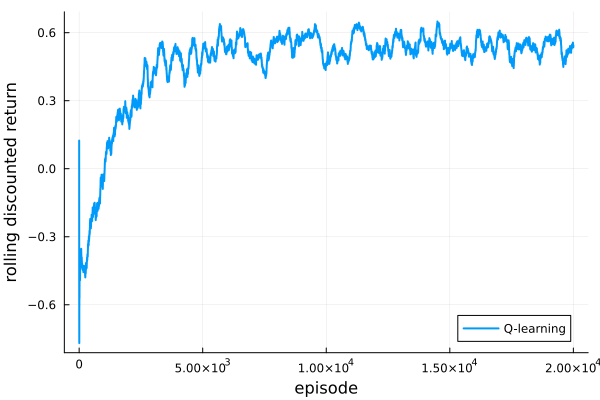

In [4]:
window = 200
smoothed = [mean(learned.returns[max(1, i-window+1):i]) for i in eachindex(learned.returns)]
plot(smoothed; lw = 2, xlabel = "episode", ylabel = "rolling discounted return", label = "Q-learning")


## Summary

The seeded learner reaches a positive-return policy despite stochastic slips. The return trace remains noisy because interaction is noisy; convergence should be assessed across seeds and against a reference when one is available.
